# Why Standard Dense ANNs Struggle with Images

## Lesson: Why ordinary ANNs struggle with images

A standard artificial neural network (ANN), also called a **fully connected** or **dense** network, can learn patterns from numbers. An image is also numbers, so an ANN *can* be trained on images. The important question is whether the way a dense network handles those numbers preserves the useful structure in an image.

In this lesson, we will follow one image from its pixels into a neural network. We will see what flattening does, why dense connections can become expensive, why pixel location matters, and how a large number of parameters can make overfitting easier. The goal is not to say that ANNs can never classify images: it is to understand why they are often an inefficient first choice for raw images.

### By the end, you should be able to

- Describe an image as a grid of pixels and channels.
- Explain how a dense ANN accepts an image after it is flattened.
- Estimate the number of weights in a dense layer.
- Explain what spatial information means and why flattening makes it harder to use.
- Connect a large parameter count with computation and overfitting.
- Explain, at a high level, why convolutional neural networks (CNNs) are a better fit for many image tasks.

### The path through the lesson

**Image → pixel values → flattened vector → dense layer → limitations → CNN intuition**

> Key idea: an ANN can process image pixels, but a dense layer does not naturally know which pixels are neighbors or which patterns repeat across an image.

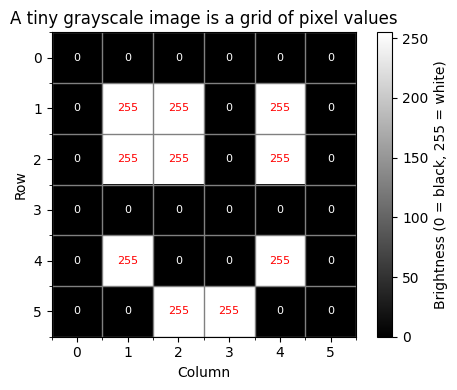

In [1]:
import matplotlib.pyplot as plt
import numpy as np

pixels = np.array([
    [0, 0, 0, 0, 0, 0],
    [0, 255, 255, 0, 255, 0],
    [0, 255, 255, 0, 255, 0],
    [0, 0, 0, 0, 0, 0],
    [0, 255, 0, 0, 255, 0],
    [0, 0, 255, 255, 0, 0],
])

fig, ax = plt.subplots(figsize=(5, 4))
image = ax.imshow(pixels, cmap="gray", vmin=0, vmax=255)
for row in range(pixels.shape[0]):
    for column in range(pixels.shape[1]):
        ax.text(column, row, str(pixels[row, column]), ha="center", va="center",
                color="red" if pixels[row, column] > 127 else "white", fontsize=8)
ax.set_title("A tiny grayscale image is a grid of pixel values")
ax.set_xlabel("Column")
ax.set_ylabel("Row")
ax.set_xticks(range(pixels.shape[1]))
ax.set_yticks(range(pixels.shape[0]))
ax.set_xticks(np.arange(-0.5, pixels.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, pixels.shape[0], 1), minor=True)
ax.grid(which="minor", color="gray", linewidth=1)
fig.colorbar(image, ax=ax, label="Brightness (0 = black, 255 = white)")
plt.tight_layout()
plt.show()

## 1. An image is structured data

An image is not one long mysterious object. It is a rectangular **grid**. Each square is a **pixel** (picture element), and each pixel stores one or more numbers describing its color.

In the grayscale example above, a pixel value of `0` means black and `255` means white; values between them are shades of gray. The array has 6 rows and 6 columns, so its shape is `(6, 6)` and it contains 36 values.

A color image commonly has three channels: **red, green, and blue (RGB)**. Its shape is often written as `(height, width, 3)`. For example, a 32-by-32 RGB image contains `32 × 32 × 3 = 3,072` numbers. Some image formats store values from 0 to 255; machine-learning pipelines often scale them to a range such as 0 to 1.

The grid itself carries meaning. Nearby pixels tend to describe nearby parts of an object: an edge, a curve, or a texture. This neighborhood structure will matter when we look at what a dense ANN does.

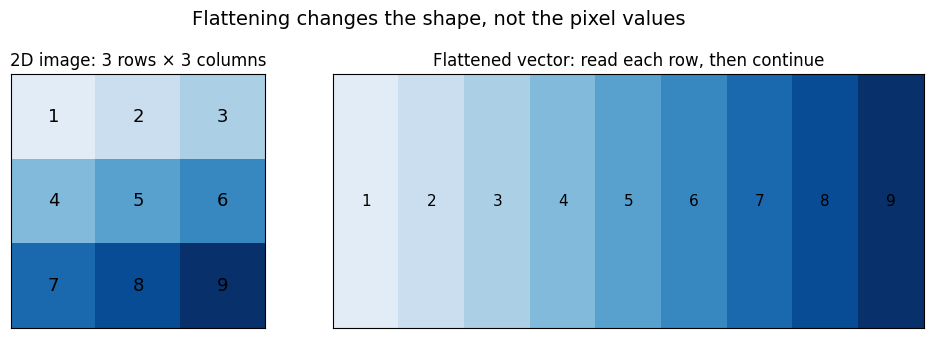

In [2]:
import matplotlib.pyplot as plt
import numpy as np

image = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
flattened = image.reshape(-1)

fig, (matrix_ax, vector_ax) = plt.subplots(1, 2, figsize=(10, 3.4), gridspec_kw={"width_ratios": [1, 1.6]})
matrix_ax.imshow(image, cmap="Blues", vmin=0, vmax=9)
for row in range(3):
    for column in range(3):
        matrix_ax.text(column, row, str(image[row, column]), ha="center", va="center", fontsize=13)
matrix_ax.set_title("2D image: 3 rows × 3 columns")
matrix_ax.set_xticks([])
matrix_ax.set_yticks([])

vector_ax.imshow(flattened.reshape(1, -1), cmap="Blues", vmin=0, vmax=9, aspect="auto")
for column, value in enumerate(flattened):
    vector_ax.text(column, 0, str(value), ha="center", va="center", fontsize=11)
vector_ax.set_title("Flattened vector: read each row, then continue")
vector_ax.set_xticks([])
vector_ax.set_yticks([])
fig.suptitle("Flattening changes the shape, not the pixel values", fontsize=14)
fig.tight_layout()
plt.show()

## 2. How a dense ANN receives an image

A basic dense ANN expects a **one-dimensional vector** of input features. To use a 2D image with it, we reshape the pixel grid into a list. This operation is called **flattening**. In the diagram above, the 3 × 3 image becomes `[1, 2, 3, 4, 5, 6, 7, 8, 9]` by reading across each row from top to bottom.

Flattening does not delete or change any pixel values. It does change how they are presented: the network receives positions in a list, rather than a height-and-width grid. A 28 × 28 grayscale image therefore becomes a vector with 784 input values; a 28 × 28 RGB image becomes 2,352 values.

A typical dense network then works like this:

1. **Input layer:** receives one number for each flattened pixel value.
2. **Hidden layer(s):** each neuron calculates a weighted sum of its inputs, adds a bias, and applies an activation function. The network learns the weights and biases during training.
3. **Output layer:** produces scores or probabilities for the possible classes, such as `cat`, `dog`, or `bird`.

In a dense layer, every neuron connects to every value in the previous layer. That is useful for general tabular features, but it creates a lot of connections for image-sized inputs.

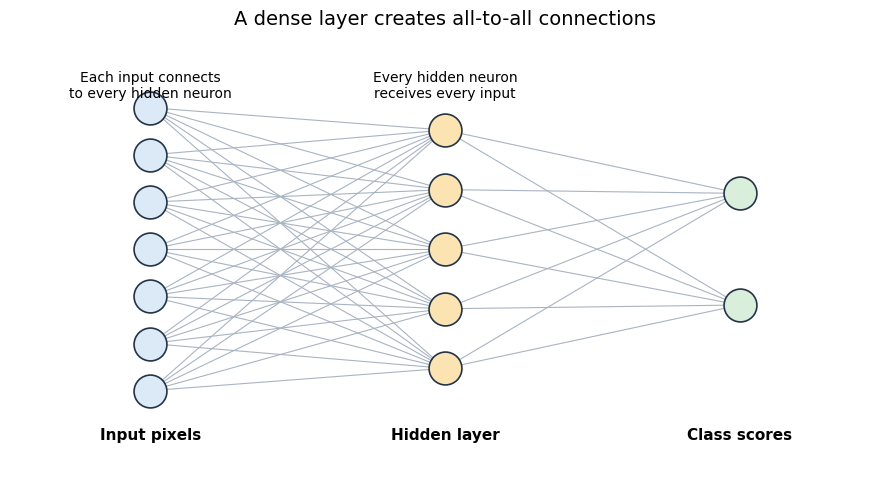

In [3]:
import matplotlib.pyplot as plt
import numpy as np

layers = [
    (0.08, np.linspace(0.12, 0.88, 7), "Input pixels"),
    (0.50, np.linspace(0.18, 0.82, 5), "Hidden layer"),
    (0.92, np.linspace(0.35, 0.65, 2), "Class scores"),
]
fig, ax = plt.subplots(figsize=(9, 5))
for layer_index in range(len(layers) - 1):
    x_left, y_left, _ = layers[layer_index]
    x_right, y_right, _ = layers[layer_index + 1]
    for y1 in y_left:
        for y2 in y_right:
            ax.plot([x_left, x_right], [y1, y2], color="#A9B4C2", linewidth=0.8, zorder=1)

colors = ["#DCEAF7", "#FCE3B2", "#D9EEDB"]
for (x, y_values, label), color in zip(layers, colors):
    ax.scatter([x] * len(y_values), y_values, s=560, color=color, edgecolor="#243447", linewidth=1.2, zorder=2)
    ax.text(x, 0.02, label, ha="center", va="top", fontsize=11, weight="bold")

ax.text(0.08, 0.98, "Each input connects\nto every hidden neuron", ha="center", va="top", fontsize=10)
ax.text(0.50, 0.98, "Every hidden neuron\nreceives every input", ha="center", va="top", fontsize=10)
ax.set_title("A dense layer creates all-to-all connections", fontsize=14, pad=14)
ax.set_xlim(-0.12, 1.12)
ax.set_ylim(-0.12, 1.05)
ax.axis("off")
fig.tight_layout()
plt.show()

## 3. Limitation one: many connections and many calculations

The network diagram shows the key rule: in a dense layer, every input connects to every neuron in the next layer. If a layer has $n_{in}$ inputs and $n_{out}$ neurons, then it needs:

- **Weights:** $n_{in} × n_{out}$
- **Biases:** $n_{out}$, usually one for each neuron
- **Total trainable parameters:** $n_{in} × n_{out} + n_{out}$

For a 28 × 28 grayscale image, there are 784 input values. Connecting them to 128 hidden neurons requires `784 × 128 = 100,352` weights, plus 128 biases: **100,480 trainable parameters in this layer alone**. For a 224 × 224 RGB image, the input has 150,528 values; connecting these to the same 128 neurons requires over 19 million weights.

Each weight participates in calculations during training and prediction. More parameters generally mean more memory and computation. They also give the model more values to learn from the training data. This is not automatically bad, but it can be wasteful when the model is trying to learn local visual patterns using a separate weight for every location.

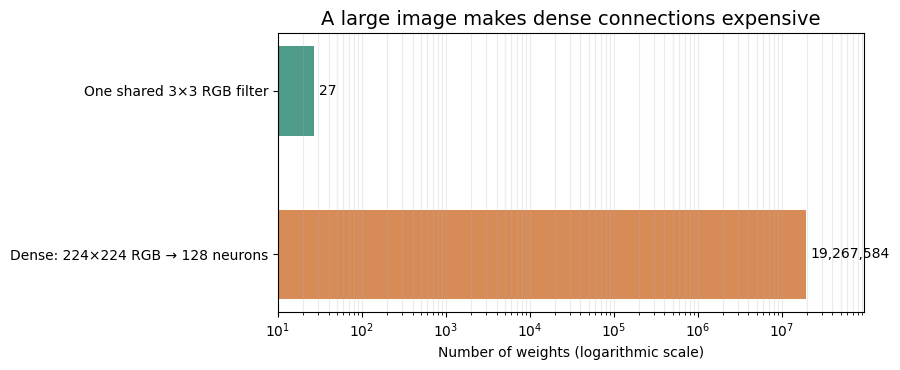

In [4]:
import matplotlib.pyplot as plt

labels = ["Dense: 224×224 RGB → 128 neurons", "One shared 3×3 RGB filter"]
parameters = [224 * 224 * 3 * 128, 3 * 3 * 3]
colors = ["#D78B57", "#4D9B88"]

fig, ax = plt.subplots(figsize=(9, 3.8))
bars = ax.barh(labels, parameters, color=colors, height=0.55)
ax.set_xscale("log")
ax.set_xlabel("Number of weights (logarithmic scale)")
ax.set_title("A large image makes dense connections expensive", fontsize=14)
ax.grid(axis="x", which="both", alpha=0.25)
for bar, value in zip(bars, parameters):
    ax.text(value * 1.15, bar.get_y() + bar.get_height() / 2, f"{value:,}", va="center", fontsize=10)
ax.set_xlim(10, max(parameters) * 5)
fig.tight_layout()
plt.show()

## 4. Limitation two: spatial relationships are not built in

In an image, **where** a pixel appears matters. A short bright line near the top-left and the same line near the bottom-right may be parts of different objects or different object positions. Nearby pixels also combine to form edges, corners, and textures.

Flattening itself does **not** throw away the values or make it mathematically impossible to learn their relationships. But after flattening, a standard dense layer has no built-in rule saying “these neighboring inputs form a small patch” or “this same edge can appear anywhere.” It must learn useful relationships from individual input positions and weights. The network is not automatically aware of the original 2D neighborhoods.

The next picture keeps the same number of bright and dark pixels in both panels. Only their locations change. The left image forms a clear shape; the right uses those same pixel values in a scrambled arrangement. This shows why a list of pixel values without a useful spatial bias can be a difficult representation for learning visual patterns.

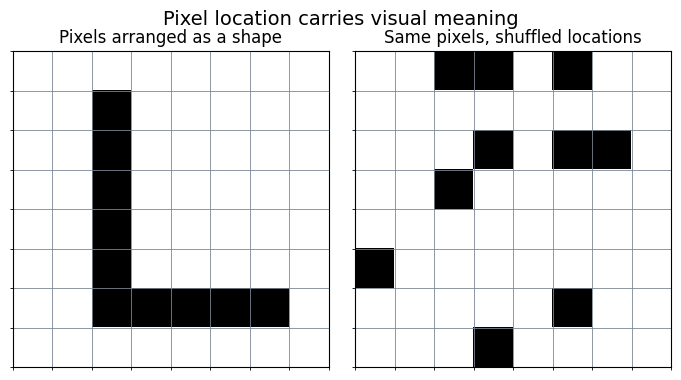

In [5]:
import matplotlib.pyplot as plt
import numpy as np

shape = np.zeros((8, 8), dtype=int)
shape[1:7, 2] = 1
shape[6, 2:7] = 1
shuffled = shape.reshape(-1).copy()
np.random.default_rng(7).shuffle(shuffled)
shuffled = shuffled.reshape(shape.shape)

fig, axes = plt.subplots(1, 2, figsize=(7, 3.8))
for ax, pixels, title in zip(axes, [shape, shuffled], ["Pixels arranged as a shape", "Same pixels, shuffled locations"]):
    ax.imshow(pixels, cmap="gray_r", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xticks(np.arange(-0.5, 8, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 8, 1), minor=True)
    ax.grid(which="minor", color="#7A8793", linewidth=0.6)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Pixel location carries visual meaning", fontsize=14)
fig.tight_layout()
plt.show()

## 5. Limitation three: overfitting can become easier

**Overfitting** happens when a model learns the training examples too closely, including accidental details or noise, and then performs poorly on new examples. It is like memorizing answers rather than learning a reusable rule.

A dense network with many parameters has many degrees of freedom. If the training set is small or repetitive, the model may fit it very well without learning patterns that generalize. A large parameter count does not guarantee overfitting: the amount and variety of data, the architecture, and training choices also matter. But unnecessary parameters can make memorization easier and increase the need for careful regularization and validation.

In the plot below, training loss keeps falling while validation loss begins to rise. The widening gap is a warning sign: improvement on training examples is no longer translating into improvement on unseen examples. In practice, we watch validation metrics and may use more varied data, data augmentation, regularization, or early stopping.

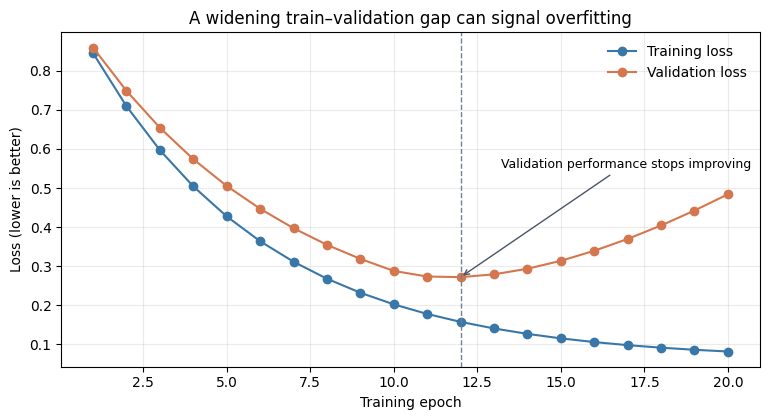

In [6]:
import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(1, 21)
training_loss = 0.95 * np.exp(-0.19 * epochs) + 0.06
validation_loss = 0.88 * np.exp(-0.16 * epochs) + 0.11 + np.maximum(epochs - 10, 0) ** 1.45 * 0.012
best_epoch = int(np.argmin(validation_loss))

fig, ax = plt.subplots(figsize=(8, 4.3))
ax.plot(epochs, training_loss, marker="o", color="#3977A8", label="Training loss")
ax.plot(epochs, validation_loss, marker="o", color="#D4774E", label="Validation loss")
ax.axvline(epochs[best_epoch], color="#718096", linestyle="--", linewidth=1)
ax.annotate("Validation performance stops improving", xy=(epochs[best_epoch], validation_loss[best_epoch]),
            xytext=(epochs[best_epoch] + 1.2, validation_loss[best_epoch] + 0.28),
            arrowprops={"arrowstyle": "->", "color": "#4A5568"}, fontsize=9)
ax.set_xlabel("Training epoch")
ax.set_ylabel("Loss (lower is better)")
ax.set_title("A widening train–validation gap can signal overfitting")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 6. Why CNNs are a natural fit for images

A **convolutional neural network (CNN)** is designed to use the layout of an image. Its key idea is to apply a small **filter** (also called a kernel) to a local patch of pixels, then slide that same filter across the image.

- **Local connections:** a filter examines nearby pixels together, so it can respond to a small feature such as an edge or corner.
- **Weight sharing:** the same filter weights are reused at many positions. If a useful edge appears in a different part of the image, the same filter can detect it there too.
- **Feature maps:** the filter produces a smaller grid of responses showing where that pattern was found. Later CNN layers combine simple patterns into more complex ones.

For example, a 3 × 3 grayscale filter uses 9 weights (plus an optional bias), regardless of whether it is applied near the top, middle, or bottom of the image. This is why the earlier comparison showed far fewer filter weights than dense-layer weights. A complete CNN has many filters and layers, so its total parameter count is larger than 9; the point is that each small filter is shared across positions.

CNNs do not make every image task easy, and they are not always necessary. A dense ANN can be perfectly reasonable for a tiny image, a small dataset, or features that have already been extracted. But for raw images, local patterns and repeated structures are so important that CNNs usually provide a more helpful starting point.

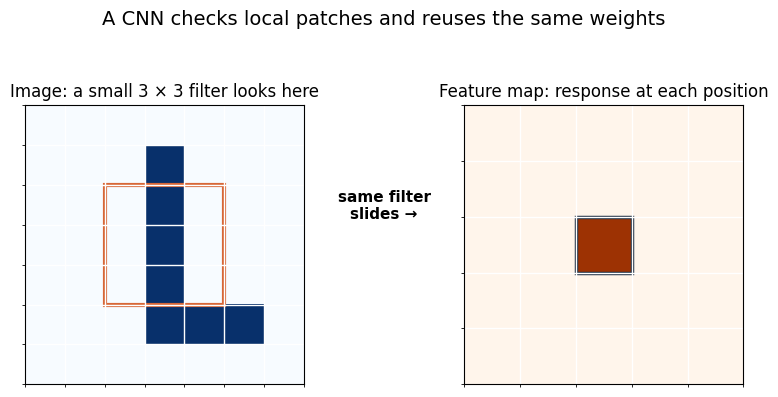

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

image = np.zeros((7, 7))
image[1:6, 3] = 1
image[5, 3:6] = 1
feature_map = np.zeros((5, 5))
feature_map[2, 2] = 0.9

fig, (image_ax, map_ax) = plt.subplots(1, 2, figsize=(9, 4))
image_ax.imshow(image, cmap="Blues", vmin=0, vmax=1)
image_ax.add_patch(Rectangle((1.5, 1.5), 3, 3, fill=False, edgecolor="#D76737", linewidth=3))
image_ax.set_title("Image: a small 3 × 3 filter looks here")
image_ax.set_xticks(np.arange(-0.5, 7, 1), minor=True)
image_ax.set_yticks(np.arange(-0.5, 7, 1), minor=True)
image_ax.grid(which="minor", color="white", linewidth=1)
image_ax.set_xticks([])
image_ax.set_yticks([])

map_ax.imshow(feature_map, cmap="Oranges", vmin=0, vmax=1)
map_ax.add_patch(Rectangle((1.5, 1.5), 1, 1, fill=False, edgecolor="#243447", linewidth=2.5))
map_ax.set_title("Feature map: response at each position")
map_ax.set_xticks(np.arange(-0.5, 5, 1), minor=True)
map_ax.set_yticks(np.arange(-0.5, 5, 1), minor=True)
map_ax.grid(which="minor", color="white", linewidth=1)
map_ax.set_xticks([])
map_ax.set_yticks([])
fig.text(0.5, 0.49, "same filter\nslides →", ha="center", va="center", fontsize=11, weight="bold")
fig.suptitle("A CNN checks local patches and reuses the same weights", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

## 7. Recap and check your understanding

### The main ideas

- An image is a grid of pixel values; a color pixel usually has red, green, and blue channel values.
- A basic dense ANN receives a vector, so an image is commonly flattened first.
- Flattening preserves the values, but a standard dense layer does not naturally use pixel neighborhoods or share the same pattern detector across locations.
- Dense layers connect every input to every neuron. For image-sized inputs, this can require many weights and calculations.
- A model with many parameters can overfit when the training examples do not provide enough varied information. Check performance on validation data, not just training data.
- CNNs use local filters and reuse their weights across the image, making them a natural choice for many image-recognition tasks.

### Quick self-check

1. How many pixel values are in a 28 × 28 grayscale image? What about a 28 × 28 RGB image?
2. Does flattening erase pixel values, or does it change their arrangement?
3. How many weights connect 784 inputs to 128 neurons in a dense layer?
4. What does it mean if training loss falls while validation loss rises?
5. What are the two helpful CNN ideas highlighted in this lesson?

<details>
<summary>Show suggested answers</summary>

1. Grayscale: `28 × 28 = 784`. RGB: `28 × 28 × 3 = 2,352`.
2. It changes the 2D grid into a 1D list; it does not remove the values.
3. `784 × 128 = 100,352` weights, plus 128 biases if the layer uses one bias per neuron.
4. The model may be overfitting: it is improving on examples it trained on but generalizing less well.
5. Local connections, which examine nearby pixels together, and weight sharing, which reuses a filter across locations.

</details>

### One-sentence takeaway

A dense ANN *can* process an image, but it treats each pixel position as an independent input and can require many learned connections; CNNs build in local pattern detection and reuse it across the image.